In [13]:
import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


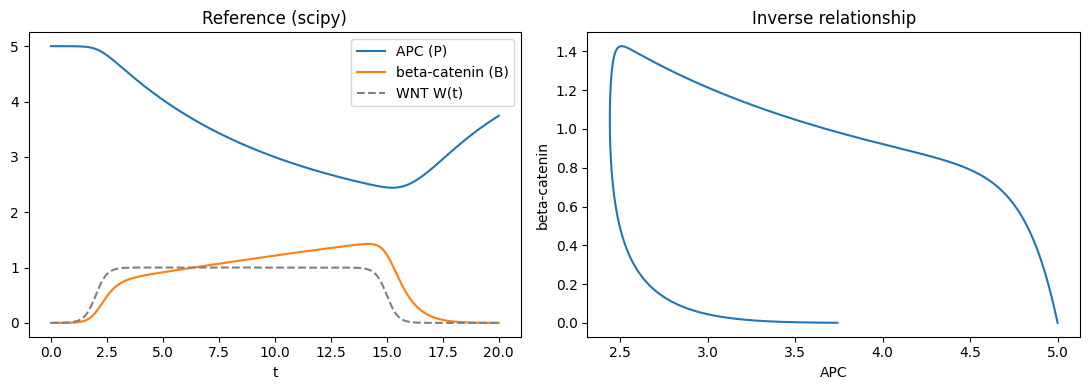

In [14]:
# Parameters (nondimensional, chosen for clean O(1) dynamics)
vP, Kb, kdeg = 1.0, 1.0, 0.2
vB, k0, kc   = 2.0, 0.1, 0.5
T = 20.0                      
t_on, t_off, ramp = 2.0, 15.0, 0.5

def W_np(t):
    return 0.5 * (np.tanh((t - t_on) / ramp) - np.tanh((t - t_off) / ramp))

def rhs(t, u):
    P, B = u
    dP = vP / (1.0 + B / Kb) - kdeg * P
    dB = vB * W_np(t) - (k0 + kc * P) * B
    return [dP, dB]

u0 = [5.0, 0.0]               # initial conditions [P, B]
t_eval = np.linspace(0.0, T, 1000)
sol = solve_ivp(rhs, (0.0, T), u0, t_eval=t_eval, method="LSODA", rtol=1e-8, atol=1e-10)
ref = sol.y.T                 # shape (1000, 2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(sol.t, ref[:, 0], label="APC (P)")
ax[0].plot(sol.t, ref[:, 1], label="beta-catenin (B)")
ax[0].plot(sol.t, W_np(sol.t), "--", color="gray", label="WNT W(t)")
ax[0].set_xlabel("t"); ax[0].legend(); ax[0].set_title("Reference (scipy)")
ax[1].plot(ref[:, 0], ref[:, 1]); ax[1].set_xlabel("APC"); ax[1].set_ylabel("beta-catenin")
ax[1].set_title("Inverse relationship")
plt.tight_layout(); plt.show()

In [15]:
# Per-variable output scales (mean magnitude of each state)
scales_np = np.maximum(np.mean(np.abs(ref), axis=0), 1e-8)   # shape (2,)
scales = torch.tensor(scales_np, dtype=torch.float32, device=device)
print("output scales:", scales_np)

# Sparse, scattered observations (supervised anchor)
n_obs = 30
obs_idx = np.sort(np.random.choice(len(sol.t), n_obs, replace=False))
t_obs = torch.tensor(sol.t[obs_idx, None], dtype=torch.float32, device=device)
u_obs = torch.tensor(ref[obs_idx], dtype=torch.float32, device=device)

# Collocation points for the ODE residual
n_col = 2000
t_col = torch.tensor(np.linspace(0, T, n_col)[:, None], dtype=torch.float32,
                     device=device, requires_grad=True)

# Initial condition
t0 = torch.zeros(1, 1, device=device)
u0_t = torch.tensor([u0], dtype=torch.float32, device=device)

output scales: [3.46039007 0.76804515]


In [16]:
class PINN(nn.Module):
    def __init__(self, n_out=2, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, n_out)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        t_scaled = t / T                 # input-scaling layer
        raw = self.net(t_scaled)         # O(1) raw outputs
        return raw * scales              # output-scaling layer

model = PINN().to(device)
print(model)

PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [17]:
def f_torch(t, u):
    P = u[:, 0:1]; B = u[:, 1:2]
    W = 0.5 * (torch.tanh((t - t_on) / ramp) - torch.tanh((t - t_off) / ramp))
    dP = vP / (1.0 + B / Kb) - kdeg * P
    dB = vB * W - (k0 + kc * P) * B
    return torch.cat([dP, dB], dim=1)

def residual(t):
    u = model(t)
    grads = [torch.autograd.grad(u[:, i].sum(), t, create_graph=True)[0]
             for i in range(u.shape[1])]
    dudt = torch.cat(grads, dim=1)
    res = dudt - f_torch(t, u)
    return res / scales                  # per-variable normalization

In [18]:
mse = nn.MSELoss()

def loss_supervised():
    L_ic = mse(model(t0), u0_t)
    L_data = mse(model(t_obs) / scales, u_obs / scales)
    return L_ic, L_data

def loss_residual():
    return (residual(t_col) ** 2).mean()

w_ic, w_data, w_res = 1.0, 1.0, 1.0

# ---- Stage 1: supervised only ----
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for it in range(1500):
    opt.zero_grad()
    L_ic, L_data = loss_supervised()
    loss = w_ic * L_ic + w_data * L_data
    loss.backward(); opt.step()
    if it % 500 == 0:
        print(f"[stage1 {it:5d}] ic={L_ic.item():.3e} data={L_data.item():.3e}")

# ---- Stage 2: add ODE residual ----
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for it in range(8000):
    opt.zero_grad()
    L_ic, L_data = loss_supervised()
    L_res = loss_residual()
    loss = w_ic * L_ic + w_data * L_data + w_res * L_res
    loss.backward(); opt.step()
    if it % 1000 == 0:
        print(f"[stage2 {it:5d}] ic={L_ic.item():.3e} "
              f"data={L_data.item():.3e} res={L_res.item():.3e}")

[stage1     0] ic=1.435e+01 data=1.132e+00
[stage1   500] ic=4.375e-05 data=2.545e-02
[stage1  1000] ic=3.754e-06 data=8.017e-03
[stage2     0] ic=1.538e-07 data=1.474e-03 res=1.582e-02
[stage2  1000] ic=2.969e-06 data=9.247e-05 res=6.889e-04
[stage2  2000] ic=5.054e-06 data=3.050e-05 res=3.993e-04
[stage2  3000] ic=3.485e-06 data=2.106e-05 res=2.818e-04
[stage2  4000] ic=4.435e-07 data=4.966e-05 res=2.530e-04
[stage2  5000] ic=3.327e-03 data=2.519e-04 res=3.309e-04
[stage2  6000] ic=2.785e-06 data=1.143e-05 res=8.357e-05
[stage2  7000] ic=6.398e-07 data=7.474e-06 res=5.217e-05


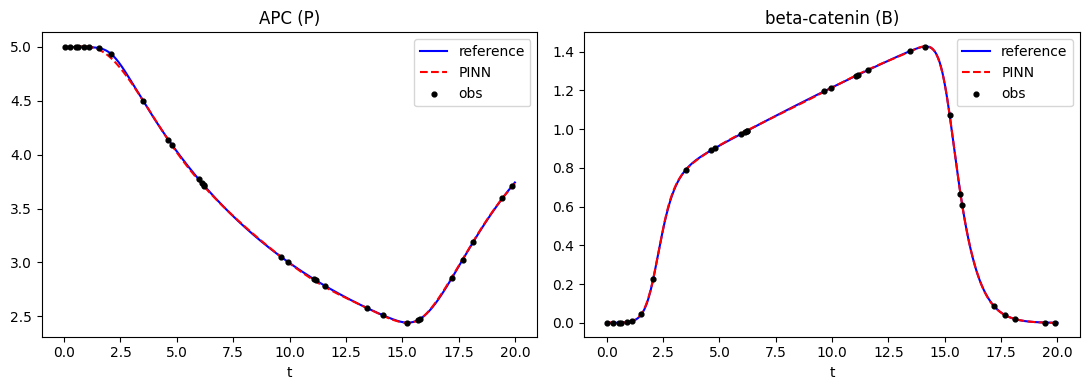

RMSE per variable: [0.01011896 0.00201559]


In [9]:
model.eval()
with torch.no_grad():
    t_test = torch.tensor(sol.t[:, None], dtype=torch.float32, device=device)
    u_pred = model(t_test).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, name in enumerate(["APC (P)", "beta-catenin (B)"]):
    ax[i].plot(sol.t, ref[:, i], "b-", label="reference")
    ax[i].plot(sol.t, u_pred[:, i], "r--", label="PINN")
    ax[i].scatter(sol.t[obs_idx], ref[obs_idx, i], s=12, c="k", zorder=3, label="obs")
    ax[i].set_xlabel("t"); ax[i].set_title(name); ax[i].legend()
plt.tight_layout(); plt.show()

rmse = np.sqrt(np.mean((u_pred - ref) ** 2, axis=0))
print("RMSE per variable:", rmse)